Special Thanks: 
group 1: Zoell, Molly, Cesar
group 2: Lily, Ashley, Diego

In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.defaule = 'colab'

from itables import show

# This stops a few warning messages from showing
pd.options.mode.chained_assignment = None 
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [7]:
# Load the data.
file_name = 'flights'
file_location = 'https://joannabieri.com/introdatascience/data/'+file_name+'.csv'
DF = pd.read_csv(file_location)
DF

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400.0,5.0,15.0,2013-01-01 10:00:00
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416.0,5.0,29.0,2013-01-01 10:00:00
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089.0,5.0,40.0,2013-01-01 10:00:00
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576.0,5.0,45.0,2013-01-01 10:00:00
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762.0,6.0,0.0,2013-01-01 11:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336771,2013,9,30,NaN,1455,NaN,NaN,1634,NaN,9E,3393,NaN,JFK,DCA,NaN,213.0,14.0,55.0,2013-09-30 18:00:00
336772,2013,9,30,NaN,2200,NaN,NaN,2312,NaN,9E,3525,NaN,LGA,SYR,NaN,198.0,22.0,0.0,2013-10-01 02:00:00
336773,2013,9,30,NaN,1210,NaN,NaN,1330,NaN,MQ,3461,N535MQ,LGA,BNA,NaN,764.0,12.0,10.0,2013-09-30 16:00:00
336774,2013,9,30,NaN,1159,NaN,NaN,1344,NaN,MQ,3572,N511MQ,LGA,CLE,NaN,419.0,11.0,59.0,2013-09-30 15:00:00


In [9]:
DF.shape

(336776, 19)

In [11]:
DF.columns

Index(['year', 'month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay',
       'arr_time', 'sched_arr_time', 'arr_delay', 'carrier', 'flight',
       'tailnum', 'origin', 'dest', 'air_time', 'distance', 'hour', 'minute',
       'time_hour'],
      dtype='object')

In [13]:
DF.dtypes

year                int64
month               int64
day                 int64
dep_time          float64
sched_dep_time      int64
dep_delay         float64
arr_time          float64
sched_arr_time      int64
arr_delay         float64
carrier            object
flight              int64
tailnum            object
origin             object
dest               object
air_time          float64
distance          float64
hour              float64
minute            float64
time_hour          object
dtype: object

In [15]:
DF.isna().sum().sort_values(ascending=False)

arr_delay         9430
air_time          9430
arr_time          8713
dep_time          8255
dep_delay         8255
tailnum           2512
year                 0
origin               0
minute               0
hour                 0
distance             0
dest                 0
carrier              0
flight               0
month                0
sched_arr_time       0
sched_dep_time       0
day                  0
time_hour            0
dtype: int64

Preliminary: There are 19 variables and over 300,000 observations giving specific flight data like departure and arrival time, flight carrier, distance, etc. There are many unknowns, almost entirely concerning flight times, with the only other unknowns being tail numbers.

In [41]:
#1
airports = pd.read_csv('https://joannabieri.com/introdatascience/data/airports.csv')

#list the top 10 destinations
top10 = DF['dest'].value_counts().nlargest(10).reset_index()
top10.columns = ['faa','flights_to']

#merge with airports data to get full name
top10 = top10.merge(airports[['faa','name']], on='faa', how='left')

#sort the from most to least flights
top10 = top10[['faa','name','flights_to']].sort_values('flights_to', ascending=False).reset_index(drop=True)
top10 

,faa,name,flights_to
0,ORD,Chicago Ohare Intl,17283
1,ATL,Hartsfield Jackson Atlanta Intl,17215
2,LAX,Los Angeles Intl,16174
3,BOS,General Edward Lawrence Logan Intl,15508
4,MCO,Orlando Intl,14082
5,CLT,Charlotte Douglas Intl,14064
6,SFO,San Francisco Intl,13331
7,FLL,Fort Lauderdale Hollywood Intl,12055
8,MIA,Miami Intl,11728
9,DCA,Ronald Reagan Washington Natl,9705


In [43]:
#2
airlines = pd.read_csv('https://joannabieri.com/introdatascience/data/airlines.csv')

#count departures by carrier code
by_carrier = DF['carrier'].value_counts().reset_index()
by_carrier.columns = ['carrier','flights']

#merge with airlines for carrier names
by_carrier = by_carrier.merge(airlines, left_on='carrier', right_on='carrier', how='left')

#sort
by_carrier = by_carrier[['carrier','name','flights']].sort_values('flights', ascending=False).reset_index(drop=True)
by_carrier

,carrier,name,flights
0,UA,United Air Lines Inc.,58665
1,B6,JetBlue Airways,54635
2,EV,ExpressJet Airlines Inc.,54173
3,DL,Delta Air Lines Inc.,48110
4,AA,American Airlines Inc.,32729
5,MQ,Envoy Air,26397
6,US,US Airways Inc.,20536
7,9E,Endeavor Air Inc.,18460
8,WN,Southwest Airlines Co.,12275
9,VX,Virgin America,5162


In [45]:
#3
#filter for non-missing arrival delay
df_arr = DF[DF['arr_delay'].notna()].copy()

#find mean arr_delay by carrier
mean_arr = df_arr.groupby('carrier')['arr_delay'].mean().reset_index().rename(columns={'arr_delay':'mean_arr_delay'})

#attach airline names
mean_arr = mean_arr.merge(airlines, on='carrier', how='left')

#highest mean arrival delay
highest = mean_arr.sort_values('mean_arr_delay', ascending=False).head(1)

#lowest mean arrival delay
lowest = mean_arr.sort_values('mean_arr_delay', ascending=True).head(1)
highest, lowest

(  carrier  mean_arr_delay                    name
 6      F9       21.920705  Frontier Airlines Inc.,
   carrier  mean_arr_delay                  name
 2      AS       -9.930889  Alaska Airlines Inc.)

Frontier airlines had the highest mean arrival delay and Alaska airlines had the lowest

In [47]:
#4
#replace missing departure delay with 0
DF['dep_delay'] = DF['dep_delay'].fillna(0)

#define time periods
bins = [0, 600, 1200, 1800, 2400]
labels = ['12am–6am', '6:01am–12pm', '12:01pm–6pm', '6:01pm–11:59pm']

#cut departure time into 4 time intervals
DF['time_period'] = pd.cut(DF['dep_time'], bins=bins, labels=labels, right=False)

# A flight is delayed if dep_delay > 0
DF['delayed'] = DF['dep_delay'] > 0

# Proportion delayed in each time period
delay_by_time = DF.groupby('time_period')['delayed'].mean().reset_index()
print(delay_by_time)

      time_period   delayed
0        12am–6am  0.177205
1     6:01am–12pm  0.246138
2     12:01pm–6pm  0.439405
3  6:01pm–11:59pm  0.569589


the proportion of delayed flights increases later in the day starting around 18% in the first time period going all the way up to 57% in the last time period. this makes sense, because each time a flight is delayed the chances of that plane being on time for the next flight is much lower

In [54]:
#5
#planes data for seat info
planes = pd.read_csv('https://joannabieri.com/introdatascience/data/planes.csv')

#find the row with the longest air time
longest = DF.loc[DF['air_time'].idxmax()]

#get destination info
dest_info = airports[airports['faa'] == longest['dest']]

# Find plane info by tail number
plane_info = planes[planes['tailnum'] == longest['tailnum']]

print("Longest air time:", longest['air_time'])
print("Destination city:", dest_info['name'].values)
print("Number of seats:", plane_info['seats'].values)

Longest air time: 695.0
Destination city: ['Honolulu Intl']
Number of seats: [292]


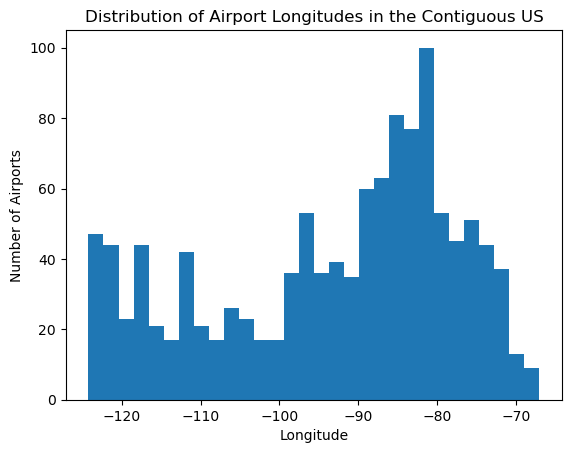

In [56]:
#6
#load airports data
airports = pd.read_csv('https://joannabieri.com/introdatascience/data/airports.csv')

#limit to Contiguous US (from Google search, rough estimates)
contig = airports[(airports['lon'] >= -125) & (airports['lon'] <= -66) &
                  (airports['lat'] >= 25) & (airports['lat'] <= 49)]

#plot
plt.hist(contig['lon'], bins=30)
plt.title('Distribution of Airport Longitudes in the Contiguous US')
plt.xlabel('Longitude')
plt.ylabel('Number of Airports')
plt.show()

with -120 being the west coast and -70 being the east coast, we see that in general there are more airports on the east side of the US than on the west. Which makes sense given how much more spread out the west is, there's fewer places needed to stop.

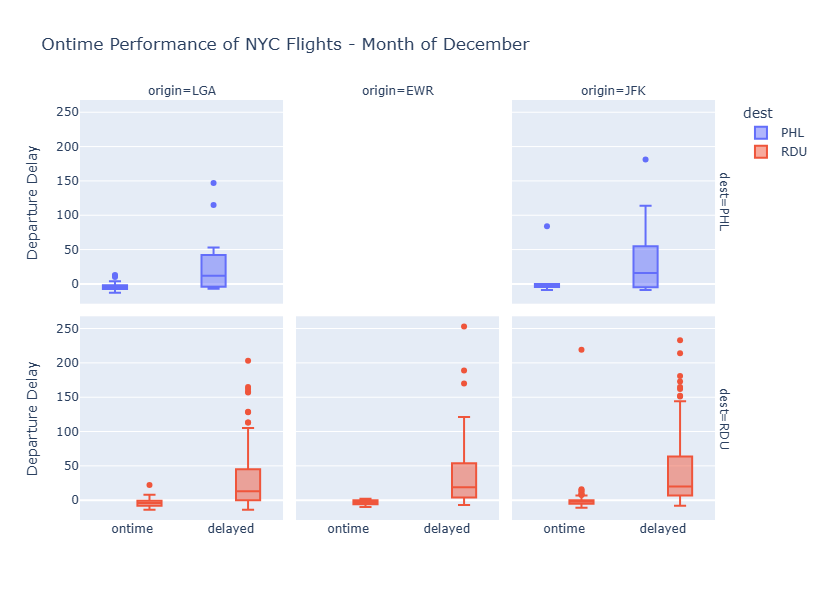

In [67]:
#7
#filter for December flights to PHL and RDU
df = DF[(DF["month"] == 12) & (DF["dest"].isin(["PHL", "RDU"]))]

#create "arrival" column
df["arrival"] = np.where(df["arr_delay"] > 0, "delayed", "ontime")

#boxplot by origin (columns) and destination (rows)
fig = px.box(
    df,
    x="arrival",
    y="dep_delay",
    color="dest",
    facet_col="origin",
    facet_row="dest",
    title="Ontime Performance of NYC Flights - Month of December",
    labels={"dep_delay": "Departure Delay", "arrival": ""}
)

fig.update_layout(height=600, width=1000)
fig.show()

The plot shows that delayed flights have much higher departure delays than on-time flights. This pattern holds across all NYC airports and destinations. The visualization shows how departure delays relate to overall on-time performance.

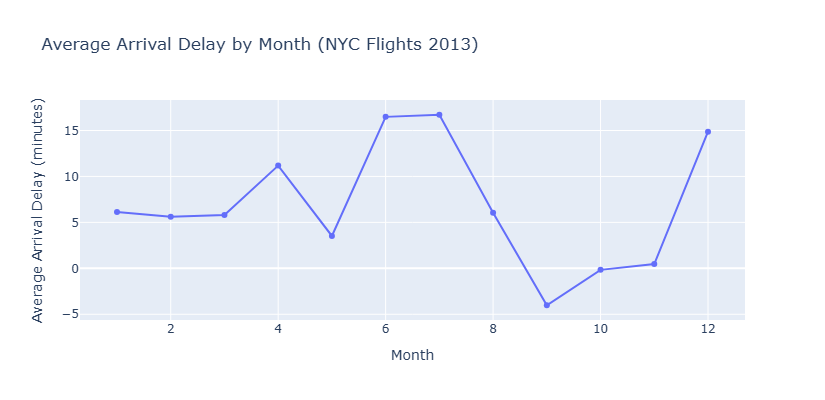

In [70]:
#create arrival column to classify flights as delayed or ontime
DF["arrival"] = np.where(DF["arr_delay"] > 0, "delayed", "ontime")

#find average arrival delay by month
avg_delay = DF.groupby("month")["arr_delay"].mean().reset_index()

#plot of average delay by month
fig = px.line(
    avg_delay,
    x="month",
    y="arr_delay",
    markers=True,
    title="Average Arrival Delay by Month (NYC Flights 2013)",
    labels={"month": "Month", "arr_delay": "Average Arrival Delay (minutes)"}
)

fig.update_layout(height=400, width=700)
fig.show()

The plot shows how average arrival delay changes throughout the year. It highlights that delays tend to increase during summer and again in december, this is likely due to these times being the most popular travel times